# Load images

In [40]:
from pathlib import Path

working_dir = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig")

rawRenderings_dir = working_dir / "1_rawRenderings"
croppedWithPositions_dir = working_dir / "2_cropped"
weights_dir = working_dir / "weights"
blue_noise_dir = working_dir / "3_blue_noise"
blue_noise_bin_dir = working_dir / "4_blue_noise_bin"
fast_noise_dir = working_dir / "5_fast_noise"

In [41]:
import re
from collections import defaultdict

from PIL import Image

pattern = re.compile(r"_lidx(\d+)of(\d+)\.png$", re.IGNORECASE)
groups = defaultdict(list)

for path in sorted(rawRenderings_dir.glob("*.png")):
    match = pattern.search(path.name)
    if not match:
        continue

    index, total = map(int, match.groups())
    series = path.name[: match.start()]
    with Image.open(path) as img:
        groups[(series, total)].append((index, path, img.copy()))

grouped_images = {}
for (series, total), items in groups.items():
    items.sort(key=lambda item: item[0])
    grouped_images[series] = {
        "expected_count": total,
        "images": [item[2] for item in items],
        "paths": [item[1] for item in items],
    }

print({series: len(data["images"]) for series, data in grouped_images.items()})


{'bokeh_fl45.0_as6_samples500000_od500': 8}


Sample series: bokeh_fl45.0_as6_samples500000_od500


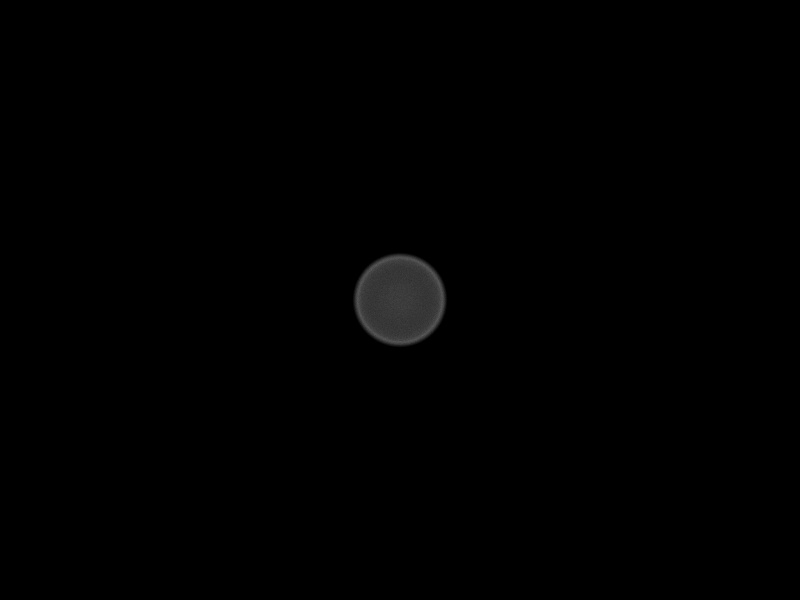

In [42]:
from IPython.display import display

first_series, data = next(iter(grouped_images.items()))
print(f"Sample series: {first_series}")
display(data["images"][0])

## Determine positions and write to text file

In [43]:
import numpy as np

records = []
for data in grouped_images.values():
    for path, image in zip(data["paths"], data["images"]):
        arr = np.asarray(image.convert("L"), dtype=float)
        total = arr.sum()
        height, width = arr.shape
        y_idx, x_idx = np.indices(arr.shape)
        cx = float((arr * x_idx).sum() / total)
        cy = float((arr * y_idx).sum() / total)
        center_x, center_y = width / 2.0, height / 2.0
        dir_x, dir_y = width - 1 - center_x, -center_y
        vec_x, vec_y = cx - center_x, cy - center_y
        denom = dir_x * dir_x + dir_y * dir_y
        t = (vec_x * dir_x + vec_y * dir_y) / denom if denom else 0.0
        t_clamped = float(np.clip(t, 0.0, 1.0))
        records.append(f"{path.name},{t_clamped:.3f}\n")
 
output_path = croppedWithPositions_dir / "positions.txt"
output_path.write_text("".join(records), encoding="utf-8")
print(f"Saved {len(records)} entries to {output_path}")

Saved 8 entries to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\2_cropped\positions.txt


In [44]:
for data in grouped_images.values():
    for path, image in zip(data["paths"], data["images"]):
        total = int(np.asarray(image.convert("L"), dtype=np.uint32).sum())
        print(f"{path.name},{total}")

bokeh_fl45.0_as6_samples500000_od500_lidx0of8.png,396594
bokeh_fl45.0_as6_samples500000_od500_lidx1of8.png,385213
bokeh_fl45.0_as6_samples500000_od500_lidx2of8.png,359201
bokeh_fl45.0_as6_samples500000_od500_lidx3of8.png,323811
bokeh_fl45.0_as6_samples500000_od500_lidx4of8.png,283080
bokeh_fl45.0_as6_samples500000_od500_lidx5of8.png,240415
bokeh_fl45.0_as6_samples500000_od500_lidx6of8.png,197210
bokeh_fl45.0_as6_samples500000_od500_lidx7of8.png,44226


### Crop bokeh and save as .pgm

In [45]:
import numpy as np
from pathlib import Path

def save_pgm_ascii(path: Path, data: np.ndarray, max_value: int = 255) -> None:
    array = np.asarray(data)
    if array.ndim != 2:
        raise ValueError("PGM images must be 2D arrays")
    clipped = np.clip(array, 0, max_value).astype(np.uint8)
    height, width = clipped.shape
    header = f"P2\n{width} {height}\n{max_value}\n"
    body = "\n".join(" ".join(str(int(pixel)) for pixel in row) for row in clipped)
    path.write_text(header + body + "\n", encoding="ascii")

In [46]:
from PIL import ImageOps

crop_boxes = {}
reference_side = None

for data in grouped_images.values():
    for path, image in zip(data["paths"], data["images"]):
        gray = image.convert("L")
        arr = np.asarray(gray)
        ys, xs = np.nonzero(arr > 0)
        if ys.size:
            cx, cy = xs.mean(), ys.mean()
            side = max(int(round(max(np.ptp(xs), np.ptp(ys))) + 1), 1)
        else:
            height, width = arr.shape
            cy, cx, side = height / 2.0, width / 2.0, max(1, min(height, width))
        reference_side = reference_side or side
        side = min(reference_side, arr.shape[0], arr.shape[1])
        half = side / 2.0
        left, top = int(round(cx - half)), int(round(cy - half))
        right, bottom = left + side, top + side
        padding = (
            max(0, -left),
            max(0, -top),
            max(0, right - arr.shape[1]),
            max(0, bottom - arr.shape[0]),
        )
        padded = ImageOps.expand(gray, border=padding, fill=0) if any(padding) else gray
        box = (
            left + padding[0],
            top + padding[1],
            right + padding[0],
            bottom + padding[1],
        )
        crop_boxes[path] = (padding, box)
        inverted = ImageOps.invert(padded.crop(box))
        save_pgm_ascii(croppedWithPositions_dir / f"{path.stem}.pgm", inverted)

### Save cropped bokeh as weights

In [47]:
for data in grouped_images.values():
    for path, image in zip(data["paths"], data["images"]):
        gray = image.convert("L")
        record = crop_boxes.get(path)
        if record is None:
            target = gray
        else:
            padding, box = record
            padded = ImageOps.expand(gray, border=padding, fill=0) if any(padding) else gray
            target = padded.crop(box)
        target.save(weights_dir / f"{path.stem}.png", format="PNG")

### Generate batch scripts to process all the noise maps

In [48]:
bat_path = working_dir / "3_generate_blue_noise.bat"

lines = []
for pgm_file in sorted((croppedWithPositions_dir).glob("*.pgm")):
    stem = pgm_file.stem
    lines.append(
        f"for /l %%x in (0, 1, 31) do ..\\Utils\\agbn\\agbn.exe -F 0 -o {croppedWithPositions_dir / stem}.pgm 16384 1000 {blue_noise_dir / stem}_%%x.txt {blue_noise_dir / stem}_%%x.png"
    )
bat_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {len(lines)} commands to {bat_path}")

Wrote 8 commands to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\3_generate_blue_noise.bat


In [49]:
bat_path = working_dir / "4_pack_blue_noise_to_bin.bat"

lines = []
for pgm_file in sorted((croppedWithPositions_dir).glob("*.pgm")):
    stem = pgm_file.stem
    lines.append(
        f"..\\Utils\\Gbn2Bin\\x64\\Release\\Gbn2Bin.exe {blue_noise_dir / stem}_ {blue_noise_bin_dir / stem}"
    )
bat_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {len(lines)} commands to {bat_path}")

Wrote 8 commands to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\4_pack_blue_noise_to_bin.bat


In [50]:
bat_path = working_dir / "5_make_fast_noise.bat"
fastnoise_root = working_dir.parent.parent / "fastnoise"
fast_noise_dir.mkdir(exist_ok=True)

lines = []
jobs = 0
for bin_file in sorted(blue_noise_bin_dir.glob("*.bin")):
    stem = bin_file.stem
    lines.extend(
        [
            f"pushd \"{fastnoise_root}\"",
            (
                "FastNoise.exe Vector2 Uniform gauss 1.0 exponential 0.1 0.1 separate "
                f"0.5 128 128 32 {stem} -split -init \"{blue_noise_bin_dir / stem}.bin\" -progress 1"
            ),
            f"for %%f in (\"{stem}*\") do move /Y \"%%f\" \"{fast_noise_dir}\"",
            "popd",
        ]
    )
    jobs += 1

bat_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Prepared {jobs} FastNoise runs in {bat_path}")

Prepared 8 FastNoise runs in C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\5_make_fast_noise.bat
